PROJECT 3 AUTHORS:
- MATEUSZ OSAK
- KRZYSZTOF DĄBROWSKI
- SZYMON DOMAŃSKI

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cooler
import cooltools
from scipy.signal import find_peaks
import subprocess
import urllib.request
import seaborn as sns
from matplotlib.patches import Rectangle
from matplotlib.patches import Patch
import pandas as pd

In [ ]:



os.makedirs("./data", exist_ok=True)

# 1. dane hic
hic_url = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE63nnn/GSE63525/suppl/GSE63525_IMR90_combined_30.hic"

# 2. Referencja TAD-ów 
tads_url = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE63nnn/GSE63525/suppl/GSE63525_IMR90_Arrowhead_domainlist.txt.gz"

# 3. do czesci 5
loops_url = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE63nnn/GSE63525/suppl/GSE63525_IMR90_HiCCUPS_looplist.txt.gz"

#for url in [hic_url, tads_url, loops_url]:
    
   # fname = os.path.join("./data", url.split("/")[-1])
   # if not os.path.exists(fname):
    #  print(f"Pobieram {url.split('/')[-1]}...")
    #  urllib.request.urlretrieve(url, fname)
   #   print(f"  OK: {fname} ({os.path.getsize(fname)/1e6:.0f} MB)")

In [3]:
hic_path = "./data/GSE63525_IMR90_combined_30.hic"

cool_25k  = "./data/IMR90_25k.cool"
cool_250k = "./data/IMR90_250k.cool"


if not os.path.exists(cool_25k):
    subprocess.run(["hic2cool", "convert", hic_path, cool_25k, "-r", "25000"], check=True)


if not os.path.exists(cool_250k):
    subprocess.run(["hic2cool", "convert", hic_path, cool_250k, "-r", "250000"], check=True)



In [4]:
mcool_path = "./data/IMR90_25k.cool"

Pobrany plik to in situ Hi-C dla linii IMR-90 (ludzkie fibroblasty płucne) z publikacji Rao et al., Cell 2014 (GSE63525). Pełnogenomowe, MAPQ≥30, mapowanie do hg19.

## 1. Hi-C Data Visualization

In [5]:
chrom = "17"
start = 30_000_000
end   = 35_000_000
region = f"{chrom}:{start}-{end}"

clr = cooler.Cooler(mcool_path)
print(clr.chromsizes)

mat = clr.matrix(balance=False).fetch(region).astype(float)
print("Kształt macierzy:", mat.shape)
print(f"Min: {mat.min():.0f}, Max: {mat.max():.0f}, Mediana: {np.median(mat):.0f}")

name
1     249250621
2     243199373
3     198022430
4     191154276
5     180915260
6     171115067
7     159138663
8     146364022
9     141213431
10    135534747
11    135006516
12    133851895
13    115169878
14    107349540
15    102531392
16     90354753
17     81195210
18     78077248
19     59128983
20     63025520
21     48129895
22     51304566
X     155270560
Y      59373566
MT        16569
Name: length, dtype: int32
Kształt macierzy: (200, 200)
Min: 0, Max: 3670, Mediana: 6


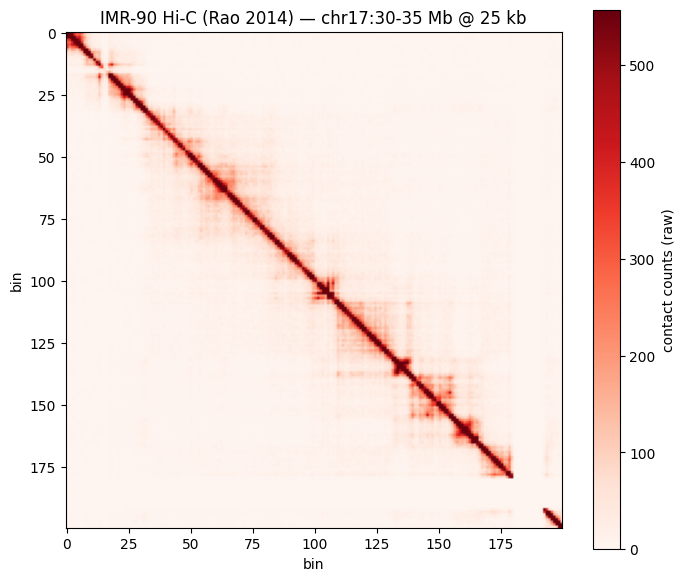

In [6]:
plt.figure(figsize=(8, 7))

vmax = np.nanpercentile(mat, 99)

plt.imshow(mat, cmap="Reds", vmax=vmax)
plt.colorbar(label="contact counts (raw)")
plt.title(f"IMR-90 Hi-C (Rao 2014) — chr{chrom}:{start/1e6:.0f}-{end/1e6:.0f} Mb @ 25 kb")
plt.xlabel("bin")
plt.ylabel("bin")
plt.show()

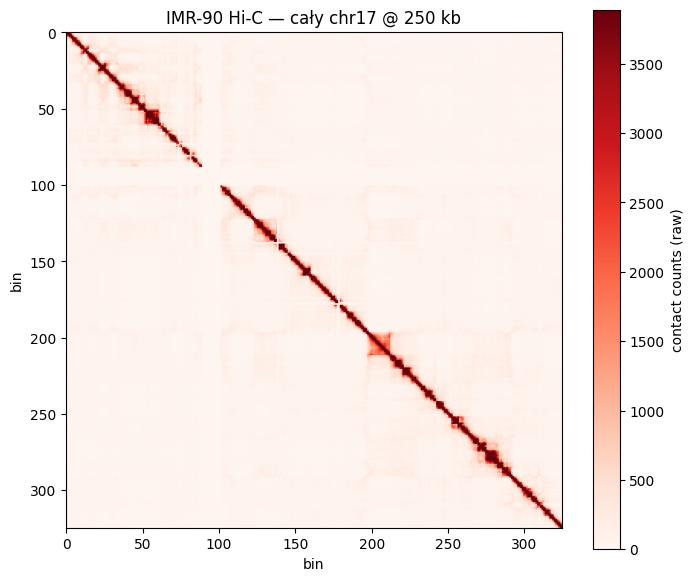

In [7]:
clr_low = cooler.Cooler("./data/IMR90_250k.cool")  
mat_whole = clr_low.matrix(balance=False).fetch(chrom).astype(float)

plt.figure(figsize=(8, 7))
plt.imshow(mat_whole, cmap="Reds", vmax=np.nanpercentile(mat_whole, 99))
plt.colorbar(label="contact counts (raw)")
plt.title(f"IMR-90 Hi-C — cały chr{chrom} @ 250 kb")
plt.xlabel("bin"); plt.ylabel("bin")
plt.show()

Skupmy się na  rozdzielczości 25 kb, mamy tam bardziej widoczne TADY.

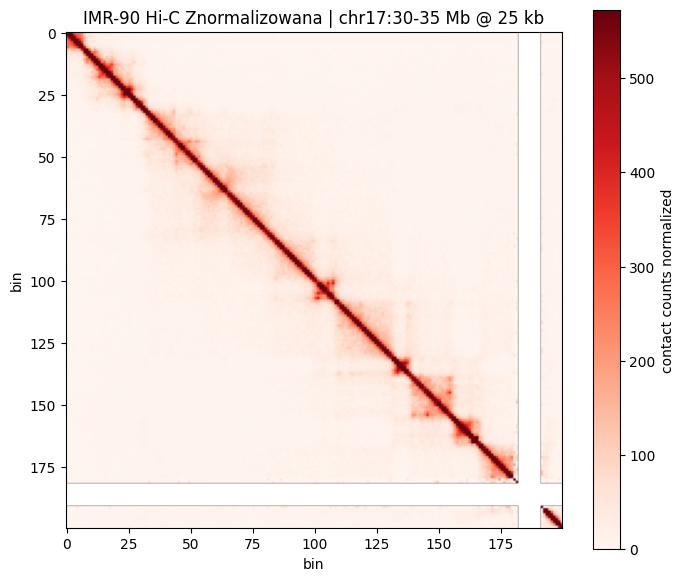

In [8]:


mat_norm = clr.matrix(balance='KR').fetch(region).astype(float)


plt.figure(figsize=(8, 7))

vmax_norm = np.nanpercentile(mat_norm, 99)

plt.imshow(mat_norm, cmap="Reds", vmax=vmax_norm)
plt.colorbar(label=f"contact counts normalized")
plt.title(f"IMR-90 Hi-C Znormalizowana | chr{chrom}:{start/1e6:.0f}-{end/1e6:.0f} Mb @ 25 kb")
plt.xlabel("bin")
plt.ylabel("bin")
plt.show()

Wnioski:


### Wnioski z wizualizacji macierzy kontaktów Hi-C:
1. **Analiza rozdzielczości i skali:** Porównanie macierzy dla całego chromosomu 17 (rozdzielczość 250 kb) z wyciętym regionem docelowym 30-35 Mb (25 kb) ukazuje 
charakterystyczną, hierarchiczną strukturę chromatyny. Dla większej rozdzielczości mało wyraźnie, jednak zauwaalna jest 
szachownica sugerująca podział chromatyny na sekcję A i B, a po zmniejszeniu rozdzielczości obserwujemy zagęszczenia kontaktów wzdloz przekątnej sugerujące istnienie TADów.
2. **Wpływ normalizacji**: Normalizacja sprawia, ze latwiej wizualnie zaobserwowac nam granicę między domenami TADów. Do normalizacji uzylismy algorytmu 
Knight-Ruiz wbudowanego w bibliotekę cooler.

## 2 TAD Detection

In [9]:


def compute_insulation_score(mat, window=5):
    """Compute insulation score for TAD boundary detection."""
    n = mat.shape[0]
    insulation = np.zeros(n)
    for i in range(n):
        s = max(0, i - window)
        e = min(n, i + window + 1)
        submat = mat[s:e, s:e]
        insulation[i] = submat.sum()
    return insulation


def detect_tad_boundaries(insulation, smooth=3):
    """Detect TAD boundaries as local minima in insulation score."""
    n = len(insulation)
    if smooth:
        ins_cs = np.cumsum(insulation)
        ins_cs[smooth:] = ins_cs[smooth:] - ins_cs[:-smooth]
        insulation[smooth // 2:-smooth // 2 + 1] = ins_cs[smooth - 1:] / smooth
    boundaries = [
        i for i in range(1, n - 1)
        if insulation[i] < insulation[i - 1] and insulation[i] < insulation[i + 1]
    ]
    return boundaries


def get_tad_regions(boundaries, n_bins):
    """Convert TAD boundaries to a list of TAD regions (start, end)."""
    regions = []
    s = 0
    for b in boundaries:
        regions.append((s, b))
        s = b
    regions.append((s, n_bins))
    return regions

In [10]:
mat_clean = np.nan_to_num(mat)

# Insulation z większym oknem + filtr na głębokość minimum
ins = compute_insulation_score(mat_clean, window=5)  # było 5 -> daj 10

# Wykryj granice + odfiltruj słabe
raw_boundaries = detect_tad_boundaries(ins.copy(), smooth=3)

# Filtr: minimum musi być wyraźnie głębsze niż otoczenie
# (prosty próg: różnica do mediany sąsiadów min. 5% globalnej amplitudy)
threshold = 0.01 * (np.max(ins) - np.min(ins))

boundaries_ins = []
for b in raw_boundaries:
    # głębokość minimum = średnia sąsiadów - wartość w minimum
    neighbors = np.concatenate([ins[max(0, b-5):b], ins[b+1:b+6]])
    depth = neighbors.mean() - ins[b]
    if depth > threshold:
        boundaries_ins.append(b)

print(f"Insulation:  {len(boundaries_ins)} ")

Insulation:  13 


In [34]:
def directionality_index(matrix, window=10):
    """
    Dla każdego binu i:
      A = suma kontaktów w lewo (i-window do i)
      B = suma kontaktów w prawo (i do i+window)
      DI = znak(B-A) * skala
    DI silnie ujemne -> koniec TAD, silnie dodatnie -> początek nowego TAD.
    Granica = zmiana znaku z minusa na plus.
    """
    n = matrix.shape[0]
    di = np.zeros(n)
    for i in range(window, n - window):
        A = matrix[i, i - window:i].sum()
        B = matrix[i, i + 1:i + window + 1].sum()
        E = (A + B) / 2
        if E > 0:
            di[i] = ((B - A) / (B + A + 1e-10)) * (((A - E) ** 2 + (B - E) ** 2) / E)
    return di


# Directionality z filtrem na siłę
di = directionality_index(mat_clean, window=10)

# Granice = zmiana znaku, ALE wymagamy żeby DI był wyraźnie ujemny przed
# i wyraźnie dodatni po (nie tylko drobne wahnięcie koło zera)
di_threshold = 0.07 * np.std(di)

boundaries_di = []
for i in range(3, len(di) - 3):
    # przed granicą DI silnie ujemne (średnia 3 poprzednich)
    before = di[i-3:i].mean()
    # po granicy DI silnie dodatnie
    after = di[i:i+3].mean()
    if before < -di_threshold and after > di_threshold:
        boundaries_di.append(i)

print(f"Directionality: {len(boundaries_di)} granic po filtrze")

Directionality: 15 granic po filtrze


In [12]:


# referencyjne tady
tads_ref = pd.read_csv("./data/GSE63525_IMR90_Arrowhead_domainlist.txt.gz", sep="\t")

print(tads_ref.columns.tolist())
print(tads_ref.head())
target_chrom = chrom.replace("chr", "") 




tads_in_region = tads_ref[
    (tads_ref["chr1"].astype(str) == target_chrom) &
    (tads_ref["x1"] >= start) &
    (tads_ref["x2"] <= end)
].copy()

print(f"TADów referencyjnych w regionie: {len(tads_in_region)}")


resolution = 25_000
ref_positions_bp = sorted(set(
    list(tads_in_region["x1"]) + list(tads_in_region["x2"])
))

ref_boundaries = [(pos - start) // resolution for pos in ref_positions_bp]
ref_boundaries = [b for b in ref_boundaries if 0 <= b < mat.shape[0]]

['chr1', 'x1', 'x2', 'chr2', 'y1', 'y2', 'color', 'f1', 'f2', 'f3', 'f4', 'f5']
  chr1         x1         x2 chr2         y1         y2      color       f1  \
0    1  120740000  121360000    1  120740000  121360000  255,255,0  0.66255   
1    1  104330000  106930000    1  104330000  106930000  255,255,0  0.44089   
2    1  101950000  104140000    1  101950000  104140000  255,255,0  0.59225   
3    1  101960000  103790000    1  101960000  103790000  255,255,0  1.06700   
4    1  152470000  153270000    1  152470000  153270000  255,255,0  0.75464   

        f2       f3       f4       f5  
0  0.36108  0.34074  0.49532  0.57024  
1  0.34166  0.27985  0.51278  0.44290  
2  0.34728  0.24742  0.59500  0.47056  
3  0.18512  0.30434  0.79611  0.56940  
4  0.13764  0.21023  0.42812  0.73188  
TADów referencyjnych w regionie: 14


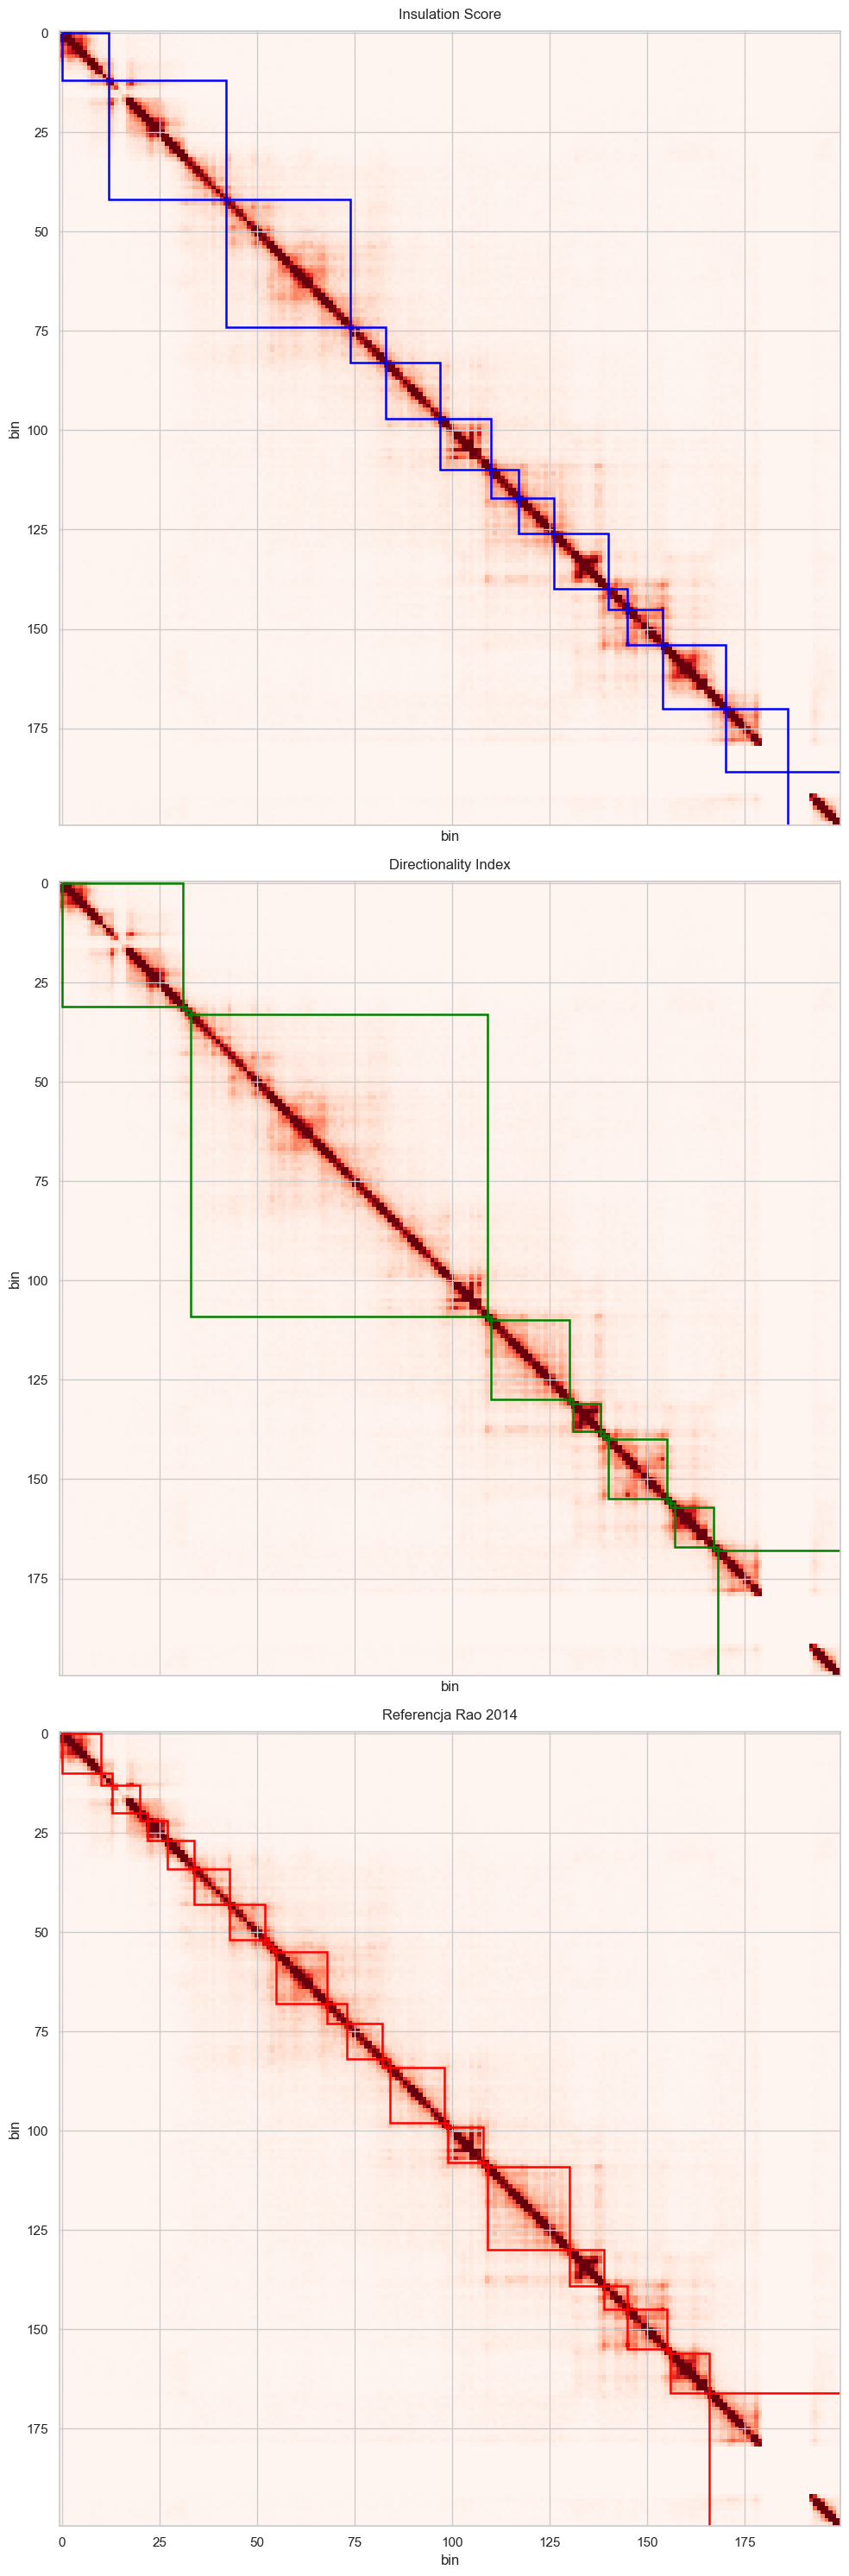

In [35]:

import numpy as np
import matplotlib.pyplot as plt

def get_tad_regions(boundaries, matrix_size):
    borders = sorted(list(set([0] + boundaries + [matrix_size])))
    return [(borders[i], borders[i+1]) for i in range(len(borders)-1)]

matrix_size = mat.shape[0]
vmax = np.nanpercentile(mat, 99)

tad_regions_ins = get_tad_regions(boundaries_ins, matrix_size)
tad_regions_di  = get_tad_regions(boundaries_di, matrix_size)
tad_regions_ref = get_tad_regions(ref_boundaries, matrix_size)


fig, axes = plt.subplots(3, 1, figsize=(10, 30), sharex=True, sharey=True)

methods_config = [
    ("Insulation Score", tad_regions_ins, "blue"),
    ("Directionality Index", tad_regions_di, "green"),
    ("Referencja Rao 2014", tad_regions_ref, "red")
]

for ax, (title, regions, color) in zip(axes, methods_config):
    ax.imshow(mat, cmap='Reds', vmax=vmax, aspect='auto')
    
    for start, end in regions:
        size = end - start
        rect = Rectangle((start, start), size, size, edgecolor=color, linewidth=1.8, fill=False)
        ax.add_patch(rect)
        
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel("bin")
    ax.set_ylabel("bin")

plt.tight_layout()
plt.show()

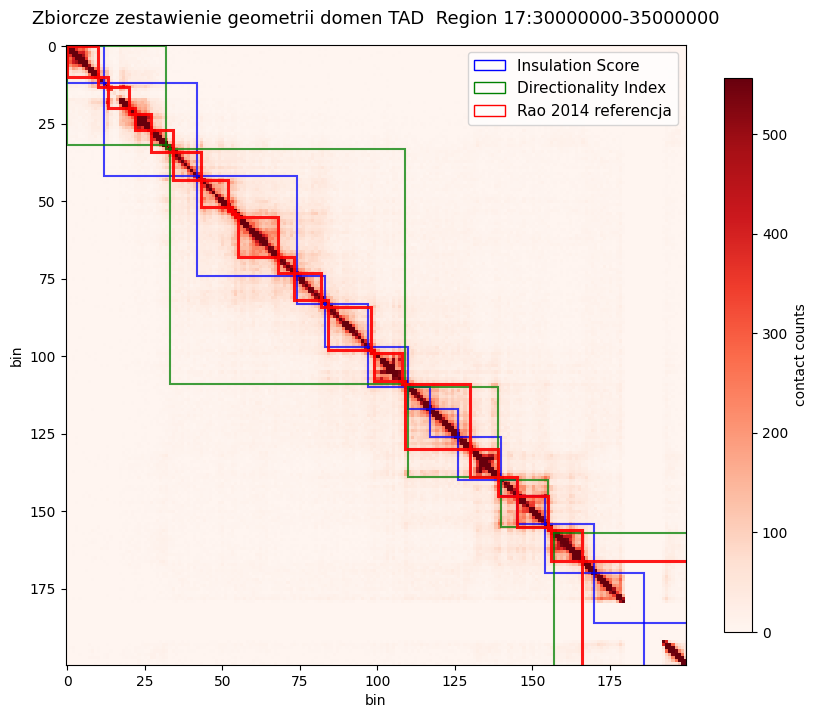

In [14]:

plt.figure(figsize=(10, 9))
ax_combined = plt.gca()


im = ax_combined.imshow(mat, cmap='Reds', vmax=vmax)

for start, end in tad_regions_ins:
    size = end - start
    ax_combined.add_patch(
        Rectangle((start, start), size, size, edgecolor='blue', linewidth=1.5, fill=False, alpha=0.75)
    )


for start, end in tad_regions_di:
    size = end - start
    ax_combined.add_patch(
        Rectangle((start, start), size, size, edgecolor='green', linewidth=1.5, fill=False, alpha=0.75)
    )

for start, end in tad_regions_ref:
    size = end - start
    ax_combined.add_patch(
        Rectangle((start, start), size, size, edgecolor='red', linewidth=2.2, fill=False, alpha=0.9)
    )

legend_elements = [
    Patch(facecolor='none', edgecolor='blue', label='Insulation Score '),
    Patch(facecolor='none', edgecolor='green', label='Directionality Index'),
    Patch(facecolor='none', edgecolor='red', label='Rao 2014 referencja')
]

ax_combined.legend(handles=legend_elements, loc='upper right', fontsize=11, frameon=True)
plt.title(f"Zbiorcze zestawienie geometrii domen TAD  Region {region}", fontsize=13, pad=15)
plt.colorbar(im, label="contact counts", shrink=0.8)
plt.xlabel("bin")
plt.ylabel("bin")
plt.show()

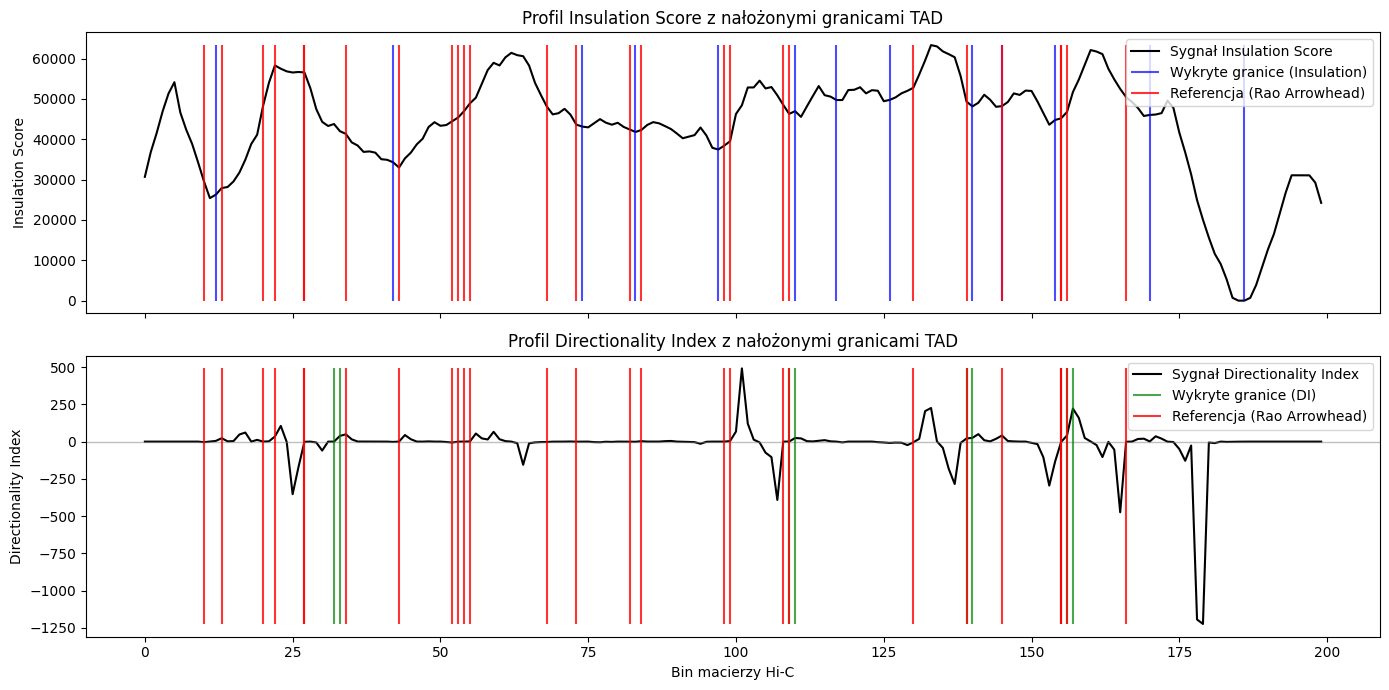

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1 = axes[0]
ax1.plot(ins, color='black', linewidth=1.5, label='Sygnał Insulation Score')


ax1.vlines(boundaries_ins, ymin=np.nanmin(ins), ymax=np.nanmax(ins), 
           color='blue', linewidth=1.5, alpha=0.7, label='Wykryte granice (Insulation)')

ax1.vlines(ref_boundaries, ymin=np.nanmin(ins), ymax=np.nanmax(ins), 
           color='red', linewidth=1.5, alpha=0.8, label='Referencja (Rao Arrowhead)')

ax1.set_title("Profil Insulation Score z nałożonymi granicami TAD", fontsize=12)
ax1.set_ylabel("Insulation Score")
ax1.legend(loc='upper right')


ax2 = axes[1]
ax2.plot(di, color='black', linewidth=1.5, label='Sygnał Directionality Index')

# Dla DI kluczowa jest linia zera, dodajemy ją dla orientacji
ax2.axhline(0, color='gray', linestyle='-', linewidth=1, alpha=0.5)

# Pionowe linie dla własnych granic (zielone, ciągłe)
ax2.vlines(boundaries_di, ymin=np.nanmin(di), ymax=np.nanmax(di), 
           color='green', linewidth=1.5, alpha=0.7, label='Wykryte granice (DI)')

# Pionowe linie dla granic referencyjnych (pomarańczowe, przerywane)
ax2.vlines(ref_boundaries, ymin=np.nanmin(di), ymax=np.nanmax(di), 
           color='red', linewidth=1.5, alpha=0.8, label='Referencja (Rao Arrowhead)')

ax2.set_title("Profil Directionality Index z nałożonymi granicami TAD", fontsize=12)
ax2.set_ylabel("Directionality Index")
ax2.set_xlabel("Bin macierzy Hi-C")
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

=== STATYSTYKI ROZKŁADU WIELKOŚCI DOMEN TAD ===


,Metoda,Liczba TAD-ów,Średnia (Mb),Mediana (Mb),Min (Mb),Max (Mb)
0,Insulation Score,14,0.357,0.338,0.125,0.8
1,Directionality Index,10,0.500,0.200,0.025,1.9
2,Rao 2014 (Ref),14,0.336,0.285,0.130,0.7


/var/folders/45/qvg2y71577g1pl9tyk8p0p640000gn/T/ipykernel_9504/2027957555.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=labels, y=combined_lengths, palette=["#9bc2e6", "#a9d18e", "#f8cbad"], ax=axes[1], width=0.5)


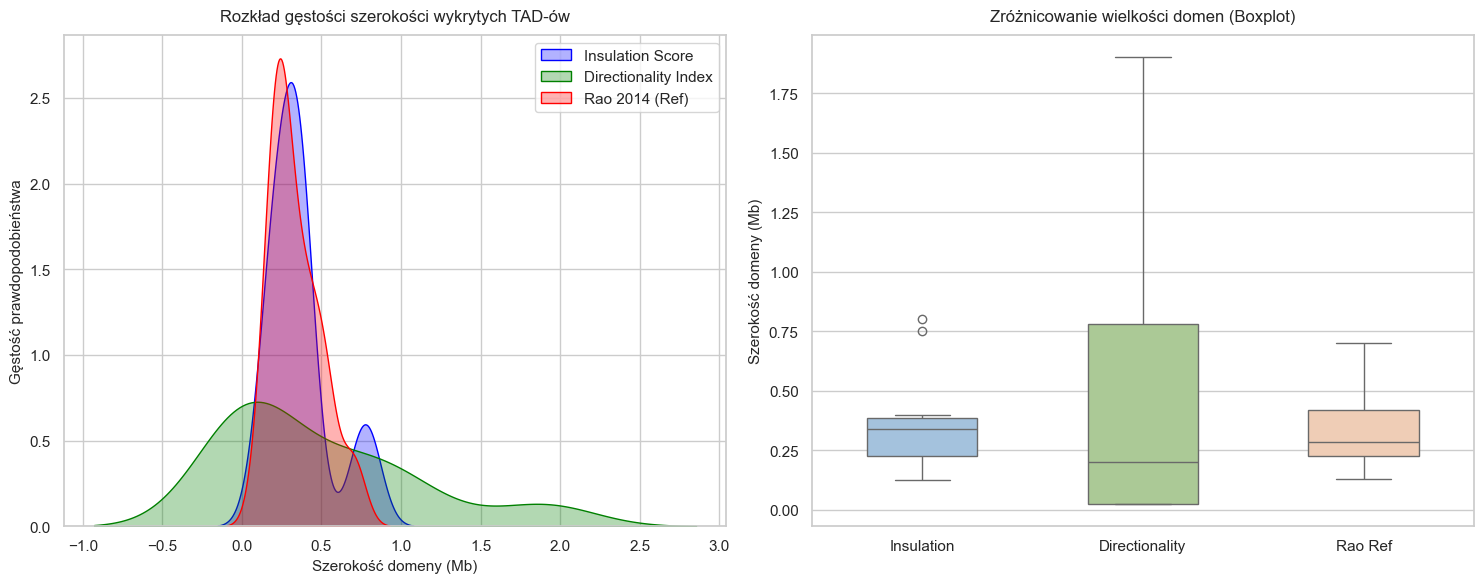

In [16]:





res_mb = 25_000 / 1e6  

def get_tad_lengths(boundaries, total_bins, res):
    full_borders = sorted(list(set([0] + boundaries + [total_bins])))
    return [(full_borders[i+1] - full_borders[i]) * res for i in range(len(full_borders)-1)]

total_bins = mat.shape[0]

lengths_ins = get_tad_lengths(boundaries_ins, total_bins, res_mb)
lengths_di  = get_tad_lengths(boundaries_di, total_bins, res_mb)

lengths_ref = ((tads_in_region["x2"] - tads_in_region["x1"]) / 1e6).tolist()

df_stats = pd.DataFrame({
    "Metoda": ["Insulation Score", "Directionality Index", "Rao 2014 (Ref)"],
    "Liczba TAD-ów": [len(lengths_ins), len(lengths_di), len(lengths_ref)],
    "Średnia (Mb)": [np.mean(lengths_ins), np.mean(lengths_di), np.mean(lengths_ref)],
    "Mediana (Mb)": [np.median(lengths_ins), np.median(lengths_di), np.median(lengths_ref)],
    "Min (Mb)": [np.min(lengths_ins), np.min(lengths_di), np.min(lengths_ref)],
    "Max (Mb)": [np.max(lengths_ins), np.max(lengths_di), np.max(lengths_ref)]
}).round(3)

print("=== STATYSTYKI ROZKŁADU WIELKOŚCI DOMEN TAD ===")
display(df_stats) 


sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))


sns.kdeplot(lengths_ins, fill=True, color="blue", label="Insulation Score", ax=axes[0], alpha=0.3, bw_adjust=0.8)
sns.kdeplot(lengths_di, fill=True, color="green", label="Directionality Index", ax=axes[0], alpha=0.3, bw_adjust=0.8)
sns.kdeplot(lengths_ref, fill=True, color="red", label="Rao 2014 (Ref)", ax=axes[0], alpha=0.3, bw_adjust=0.8)
axes[0].set_title("Rozkład gęstości szerokości wykrytych TAD-ów", fontsize=12, pad=10)
axes[0].set_xlabel("Szerokość domeny (Mb)", fontsize=11)
axes[0].set_ylabel("Gęstość prawdopodobieństwa", fontsize=11)
axes[0].legend()


combined_lengths = lengths_ins + lengths_di + lengths_ref
labels = (["Insulation"] * len(lengths_ins) + 
          ["Directionality"] * len(lengths_di) + 
          ["Rao Ref"] * len(lengths_ref))

sns.boxplot(x=labels, y=combined_lengths, palette=["#9bc2e6", "#a9d18e", "#f8cbad"], ax=axes[1], width=0.5)
axes[1].set_title("Zróżnicowanie wielkości domen (Boxplot)", fontsize=12, pad=10)
axes[1].set_ylabel("Szerokość domeny (Mb)", fontsize=11)
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

In [36]:
def precision_recall(predicted, reference, tol=1):
    """tol=1 przy 25 kb = tolerancja ±25 kb między granicami."""
    if len(predicted) == 0 or len(reference) == 0:
        return 0.0, 0.0
    matched_pred = sum(any(abs(p - r) <= tol for r in reference) for p in predicted)
    matched_ref  = sum(any(abs(r - p) <= tol for p in predicted) for r in reference)
    return matched_pred / len(predicted), matched_ref / len(reference)


p_ins, r_ins = precision_recall(boundaries_ins, ref_boundaries, tol=1)
p_di,  r_di  = precision_recall(boundaries_di,  ref_boundaries, tol=1)

print(f"{'Metoda':<25} {'# granic':>10} {'precision':>12} {'recall':>10}")
print("-" * 60)
print(f"{'Insulation (lab)':<25} {len(boundaries_ins):>10} {p_ins:>11.0%} {r_ins:>10.0%}")
print(f"{'Directionality index':<25} {len(boundaries_di):>10} {p_di:>11.0%} {r_di:>10.0%}")
print(f"{'Referencja (Rao 2014)':<25} {len(ref_boundaries):>10}")

Metoda                      # granic    precision     recall
------------------------------------------------------------
Insulation (lab)                  13         69%        41%
Directionality index              15         80%        33%
Referencja (Rao 2014)             27


## **Analiza wyników**
1. ### Dokładność
Przy konfiguracji Insulation i Directionality index obraliśmy prostą metodologię: parametry dobieramy tak, aby liczba TADów zgadzała się z danymi 
referencyjnymi. Takie proste wnioskowanie nie oddaje pełni zalet tych metod, ale równiez nie kompromituje naszych badań. 
Directinality index wykazał się większą precyzją, ale gorszym recallem. 
Insulation score dobrze radzi sobie z mapowaniem TADów o mniejszych rozmiarach. 


2.  ### Analiza wielkości TADów
Jeśli chodzi o rozkład gęstości wykrywanych TADów, to potwierdza on dobre spasowanie metody Insulation. Zarówno na boxplocie jak na wykresie gęstości,
obserwujemy duzy stopień podobieństwa między rozkładami wielkości Tadów. 

## 3. CTCF analysis

In [18]:
# totalnie nie wiem jak to zrobić

## 4. Integration with 1D data.

In [19]:
# 1d data download

In [20]:
# data vis

In [21]:
# TAD border check

In [22]:
# simple analisis wzbogacanie???

## 5. Chromatin loops detection 

In [23]:
#